In [1]:
import torch
import pickle
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import Emulator.Inference.kolmogorov.performance as performance
import Emulator.Models.misc as misc

In [2]:
#get the emulator
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

file_string = "/scratch/ql2221/thermalizer_data/wandb_data/wandb/run-20251127_115159-4m6hgwof/files/checkpoint_last.p"

emu=misc.load_model(file_string).to(device)

In [3]:
#load data
data_dict = torch.load("/scratch/ql2221/thermalizer_data/kolmogorov/reynold10k/Long_numerical_rollout.p")

sim_stack_loaded = data_dict["data"]

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x = sim_stack_loaded[1,:,:,:]/4.44
x = x.unsqueeze(0).to(device)
print(x.shape)

torch.Size([1, 50000, 64, 64])


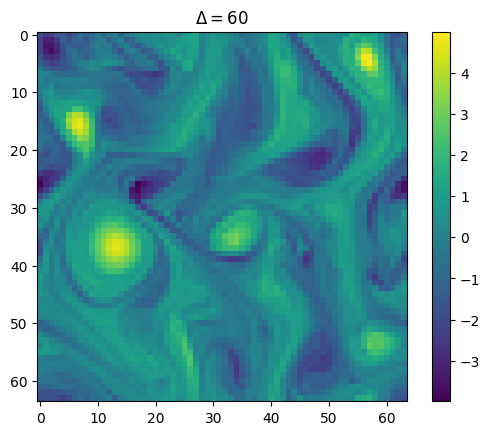

In [5]:
#peak at data
tensor = x[:,0]

# Remove the singleton dimension
tensor = tensor.squeeze(0)  # Now shape is (64, 64)

# Convert to NumPy
tensor_np = tensor.detach().cpu().numpy()

# Plot using cmocean colormap
plt.imshow(tensor_np)  # You can choose different cmocean colormaps
plt.colorbar()
plt.title(r'$\Delta = 60$')
# plt.savefig("noised.png")
plt.show()

In [7]:
ics = x[:,0:1]
emu_rollout, ens, _=performance.run_emu(ics, emu, n_steps=30000, silent=False)

100%|██████████| 29999/29999 [02:51<00:00, 174.53it/s]


In [8]:
from matplotlib import animation
def make_movie(state_vector, save_path="emulator_movie.mp4", fps=30, vmin=None, vmax=None, stride=10):
    """
    Create a movie from a 4D tensor of shape (batch, time, height, width), using only every `stride`-th frame.
    
    Parameters:
    - state_vector: torch.Tensor of shape (B, T, H, W)
    - save_path: output video file path
    - fps: frames per second for the movie
    - vmin, vmax: color scale
    - stride: only include every `stride`th frame in the video
    """
    B, T, H, W = state_vector.shape
    data = state_vector[0].cpu().numpy()

    fig, ax = plt.subplots()
    im = ax.imshow(data[0], cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_title("Timestep 0")
    fig.colorbar(im, ax=ax)

    # Frame indices to use
    frame_indices = list(range(0, T, stride))

    def update(frame_idx):
        frame = frame_indices[frame_idx]
        im.set_data(data[frame])
        ax.set_title(f"Timestep {frame}")
        return im,

    ani = animation.FuncAnimation(fig, update, frames=len(frame_indices), blit=False, repeat=False)
    ani.save(save_path, fps=fps)
    plt.close(fig)
    print("movie saved")

In [9]:
make_movie(emu_rollout, save_path="rollout.mp4", fps=30)

/ext3/miniforge3/lib/python3.12/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


movie saved


In [ ]:
make_movie(x, save_path="ground_truth.mp4", fps=30)